# 1. read gfc files, read low-degree files (TN-13, TN-14), GIA files

In [5]:
import numpy as np
import sagea
from sagea.sgio import read_low_degs
from sagea.utils import FileTool, MathTool, TimeTool

import pathlib

"""define file paths"""
paths_gfc = list(pathlib.Path(
    "/Volumes/WorkDrive/data/GRACE/L2_SH_products/GSM/ITSG/Grace2018/n60/2008/").glob("ITSG*.gfc"))
paths_gfc.sort()

path_gif48 = pathlib.Path("/Users/shuhao/PycharmProjects/SaGEA/data/auxiliary/GIF48.gfc")

path_TN13 = pathlib.Path("/Volumes/WorkDrive/data/GRACE/L2_low_degrees/TN-13_GEOC_JPL_RL06.3.txt")
path_TN14 = pathlib.Path("/Volumes/WorkDrive/data/GRACE/L2_low_degrees/TN-14_C30_C20_SLR_GSFC.txt")

path_GIA = pathlib.Path("/Users/shuhao/PycharmProjects/SaGEA/data/GIA/GIA.ICE-6G_D.txt")
pass

"""parameters"""
lmax = 60  # max degree/order

"""read files"""
shc = sagea.SHC.io.from_gfc(paths_gfc, lmax=lmax, key='gfc')
shc_gif48 = sagea.SHC.io.from_gfc(path_gif48, lmax=lmax, key='gfc')
shc -= shc_gif48  # deduct GIF48 model as background

# read low-degree files and replace
dates_begin, dates_end = TimeTool.match_dates_from_name(paths_gfc)
dates_ave = TimeTool.get_average_dates(dates_begin, dates_end)

low_deg_dict = {}
low_deg_dict.update(read_low_degs(path_TN13, dates=dates_ave))
low_deg_dict.update(read_low_degs(path_TN14, dates=dates_ave))  # {"c2,0": np.ndarray, ...}

for key in ("c1,0", "c1,1", "s1,1", "c2,0", "c3,0"):
    low_deg_dict[key] -= np.mean(low_deg_dict[key][low_deg_dict[key] == low_deg_dict[key]])
    shc.replace(key, low_deg_dict[key], inplace=True)
    # For the processing of an shc instance (replace, filtering, etc.), a new parameter, `inplace`: bool, is included, default to be False.
    # If `inplace` is set to True, it will modify the values within the instance; otherwise, it will only return the new instance.

# read GIA file and deduct shc_GIA
shc_gia_trend = sagea.SHC.io.from_gfc(path_GIA, lmax=lmax, key='')
shc_gia = sagea.SHC.generate.from_trend(shc_gia_trend, dates=dates_ave)

shc -= shc_gia


/Users/shuhao/PycharmProjects/SaGEA/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/shuhao/PycharmProjects/SaGEA/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [7]:
# temp
shc.ntime
shc.lmax
shc.degree_rms
shc.cumulative_degree_rss
shc.replace()

60

In [3]:
# shc_filtered = shc.filter.pnmm(3, 5, inplace=False)
# shc_filtered = shc_filtered.filter.gaussian(300, inplace=False)
shc_filtered = shc.filter.ddk(ddk_id=4)
# use print(shc.filter.help()) to see more usages.

shc_geometric = shc_filtered.correction.geometric(
    auto_load_actual_earth=True,
    phisfc_file="/Users/shuhao/PycharmProjects/SaGEA/src/sagea/data/auxiliary/PHISFC_ERA5_invariant.nc",
    gif48_file="/Users/shuhao/PycharmProjects/SaGEA/src/sagea/data/auxiliary/GIF48.gfc",
    inplace=False,
    verbose=True,
)

# shc_filtered.io.save_file(
#     filepath="../test_save_shc/test.gfc", index=0,
#     header="test\n ===== end of header =====\n",
#     key="gfc",
#     make_parent=True,
#     overwrite=True,
# )

geometric correction iteration 3/4
geometric correction iteration 4/4


# 3. Spherical harmonic synthesis to grid, validate, plot and save

(12, 180, 360)


KeyboardInterrupt: 

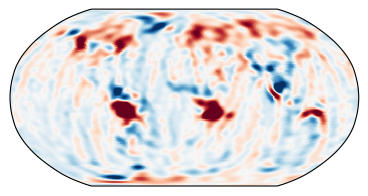

In [4]:
import cartopy

"""spherical harmonic synthesis to 1x1 gridded map of EWHA field"""
grid_space = 1  # degree
shc_filtered_ewh = shc_filtered.convert(from_type="Geopotential", to_type="EWH",
                                        inplace=False)  # convert to equivalent water height (EWH, [m])

grid = shc_filtered_ewh.synthesize.to_grid(1)
grid.value *= 100  # into unit [cm]

print(grid.value.shape)

"""plot"""
plot_index = 1
grid.plot(
    index=[plot_index],
    titles=["ITSG-Grace2018, FSC filtered", ],
    title=dates_ave[plot_index],
    gridlines=False,
    vmin=-15, vmax=15,
    projection=cartopy.crs.Robinson()
)
